Shape: (8760, 6)

Missing values:
france     0
italy      0
belgium    0
spain      0
uk         0
germany    0
dtype: int64

Summary stats (prices):


,france,italy,belgium,spain,uk,germany
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,275.892326,307.595284,244.545660,167.538025,219.655885,235.460071
std,145.814772,136.944979,134.648658,69.442260,105.460928,142.802139
min,-1.440000,1.000000,-100.000000,0.000000,-30.000000,-19.040000
25%,183.062500,211.895000,157.727500,125.000000,153.210000,134.277500
50%,239.335000,266.645000,219.865000,163.565000,219.055000,208.375000
75%,350.000000,385.000000,315.085000,206.410000,265.170000,310.080000
max,2987.780000,871.000000,871.000000,700.000000,705.470000,871.000000


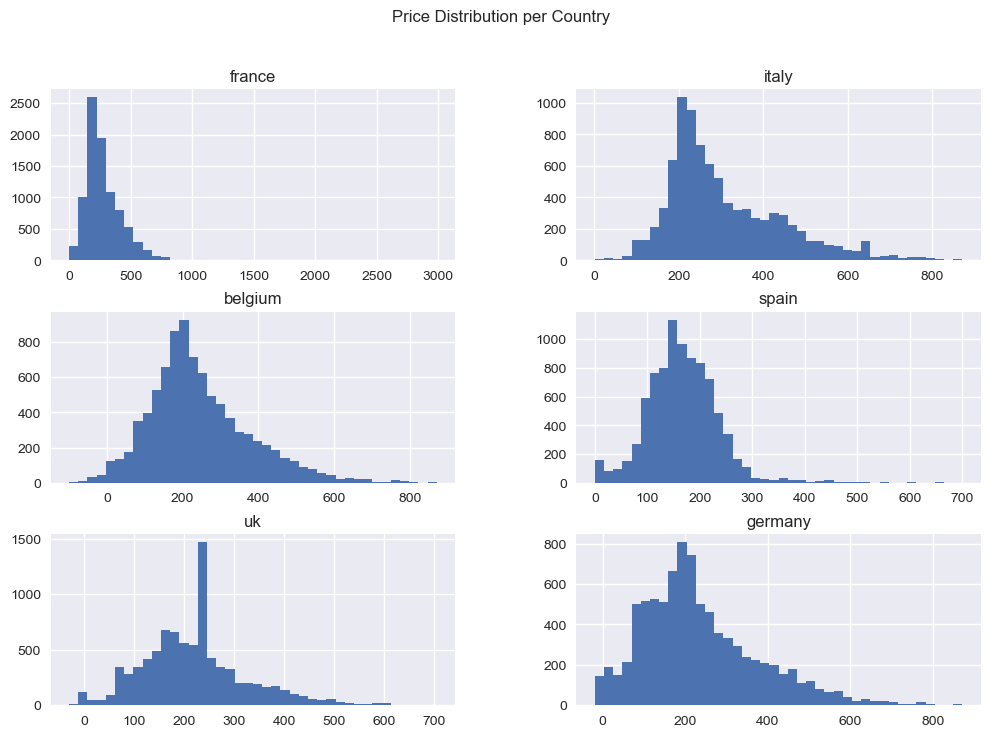

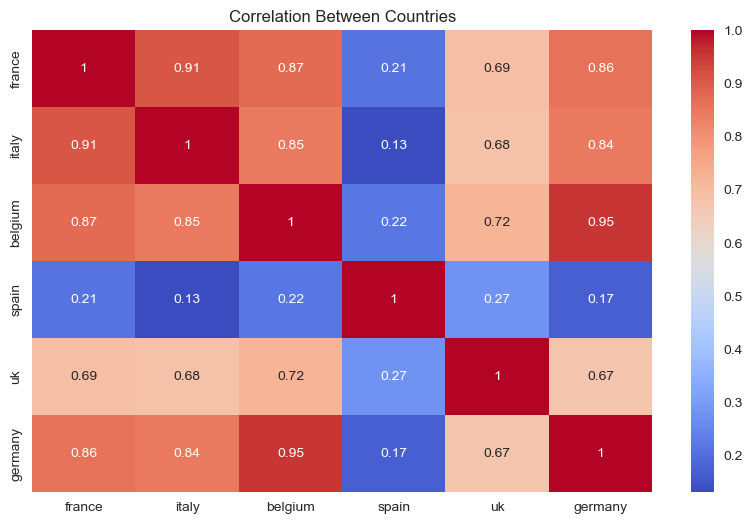

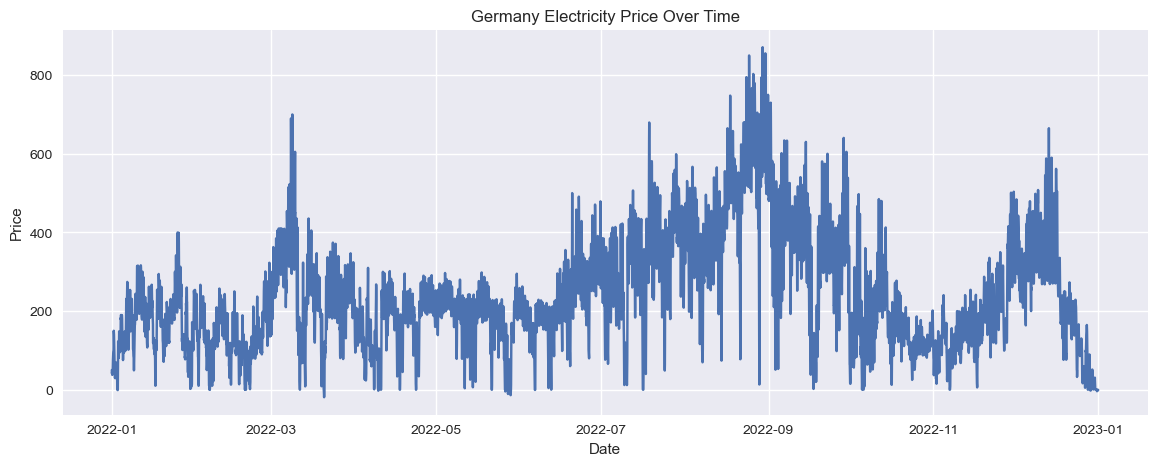

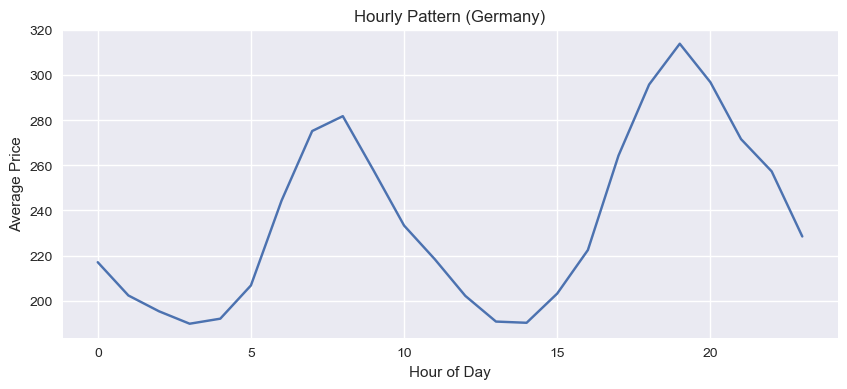

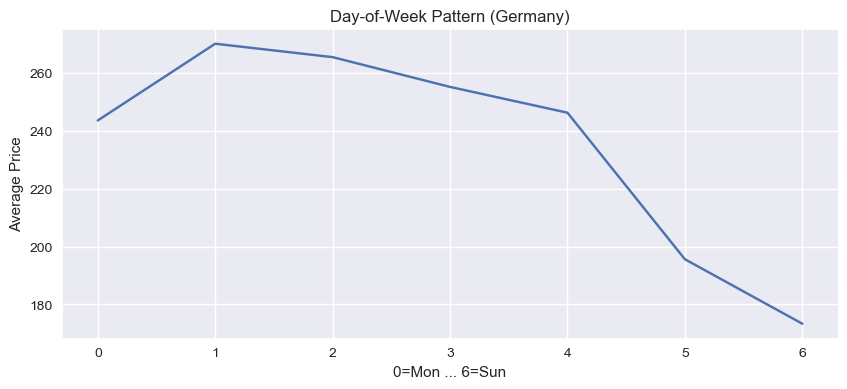

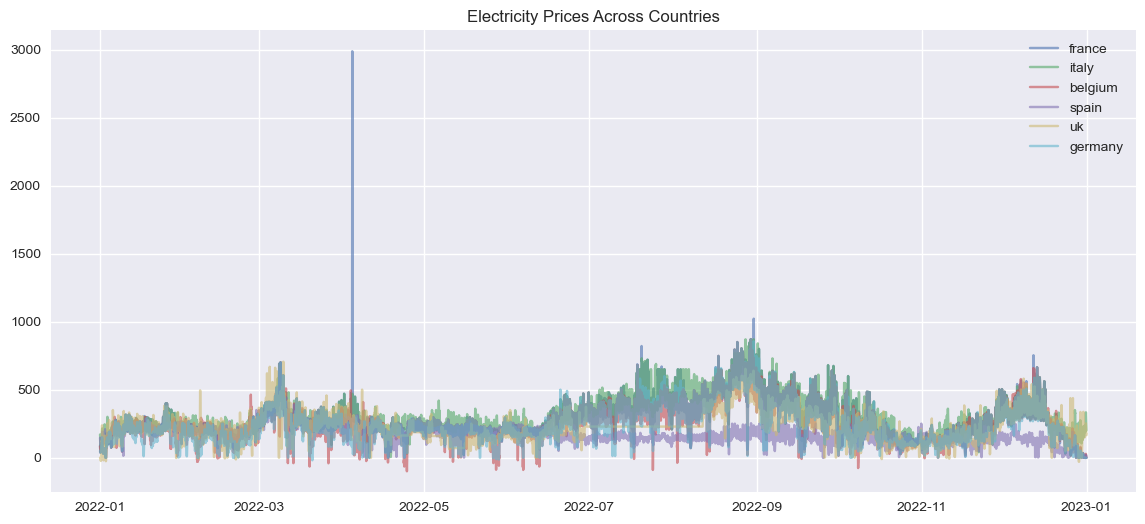

Columns in df_feat:
['france', 'italy', 'belgium', 'spain', 'uk', 'germany', 'hour_num', 'dayofweek', 'hour', 'month', 'is_weekend', 'germany_lag_1', 'germany_lag_2', 'germany_lag_24', 'germany_lag_168', 'germany_roll_mean_24', 'germany_roll_std_24', 'france_lag_1', 'italy_lag_1', 'belgium_lag_1', 'spain_lag_1', 'uk_lag_1']

=== Single-split performance ===
Naive (t-24) → MAE: 45.154, RMSE: 61.012, WAPE: 22.68%
Random Forest → MAE: 11.090, RMSE: 19.108, WAPE: 5.57%


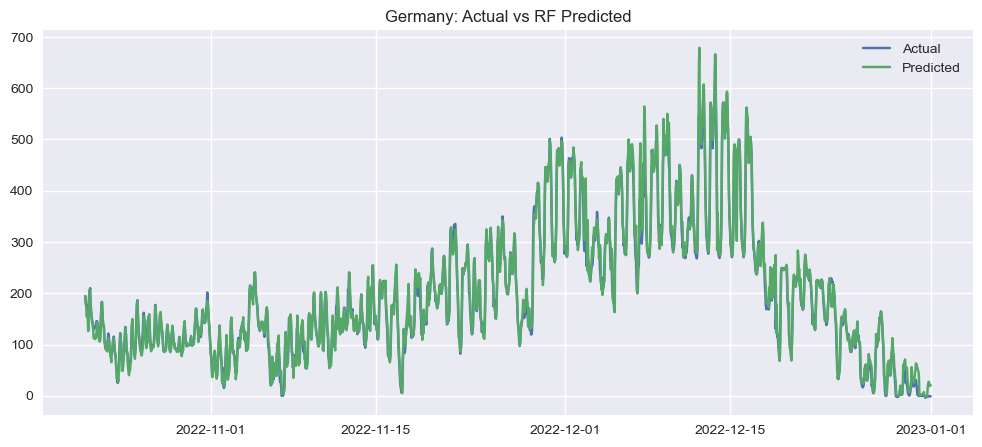

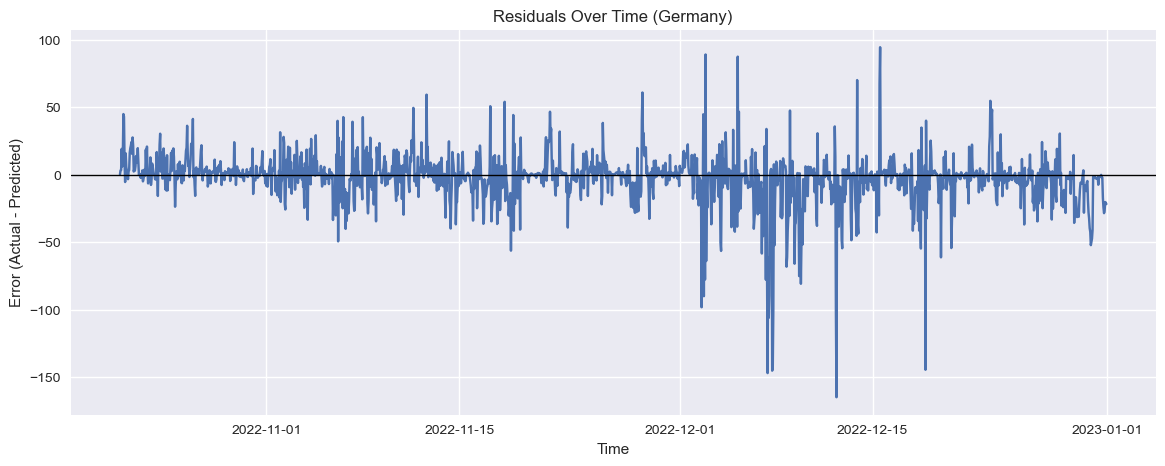

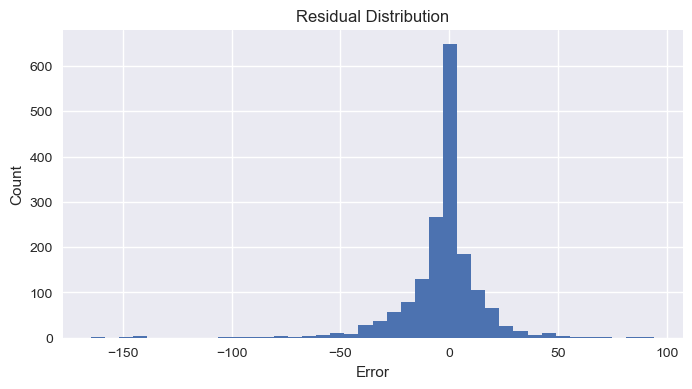


Top 20 features:


germany_lag_1           0.790032
belgium                 0.174948
france                  0.015301
germany_lag_2           0.003077
belgium_lag_1           0.003014
france_lag_1            0.001761
germany_lag_24          0.001415
germany_lag_168         0.001209
germany_roll_mean_24    0.001151
germany_roll_std_24     0.001115
spain_lag_1             0.000986
italy                   0.000942
hour_num                0.000910
hour                    0.000891
italy_lag_1             0.000706
spain                   0.000659
uk_lag_1                0.000658
uk                      0.000550
month                   0.000394
dayofweek               0.000241
dtype: float64

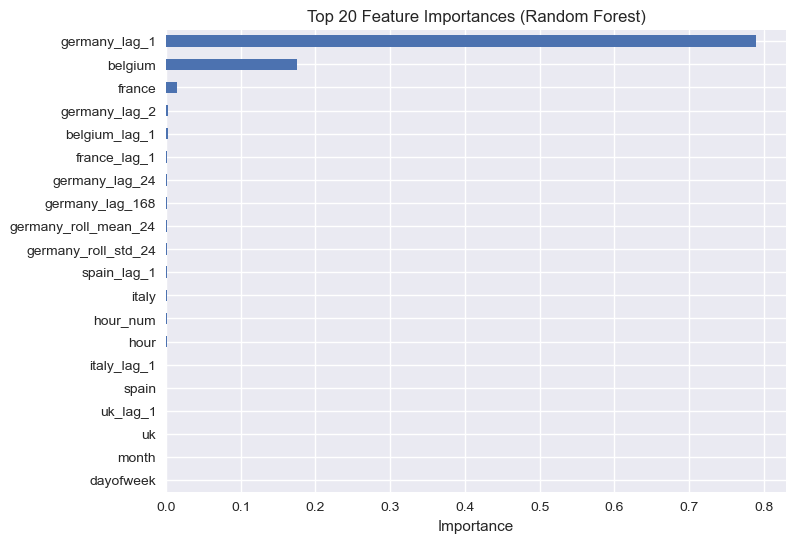


=== Walk-forward CV ===
Fold 1 → MAE: 13.032, RMSE: 21.896
Fold 2 → MAE: 9.831, RMSE: 17.380
Fold 3 → MAE: 24.144, RMSE: 38.512
Fold 4 → MAE: 13.815, RMSE: 22.154
Fold 5 → MAE: 11.809, RMSE: 20.240

Overall:
MAE: 14.526 ± 4.994
RMSE: 24.036 ± 7.435


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

plt.style.use("seaborn-v0_8")

# ============================
# 1. PREPROCESSING PIPELINE
# ============================

def load_raw_data(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    return df

def create_datetime_column(df):
    df = df.copy()
    df['hour_start'] = df['hour'].str.split('-').str[0]
    dt_str = df['date'].astype(str) + ' ' + df['hour_start'].astype(str)
    df['datetime'] = pd.to_datetime(dt_str, errors='coerce')
    df = df.drop(columns=['hour', 'date', 'hour_start'])
    df = df.sort_values('datetime').reset_index(drop=True)
    return df

def ensure_hourly_frequency(df):
    df = df.set_index('datetime')
    df = df[~df.index.duplicated(keep='first')]
    full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
    df = df.reindex(full_index)
    df.index.name = 'datetime'
    return df

def convert_prices_to_numeric(df):
    price_cols = ['france','italy','belgium','spain','uk','germany']
    for col in price_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def handle_missing_values(df):
    return df.ffill().bfill()

def preprocess(path):
    df = load_raw_data(path)
    df = create_datetime_column(df)
    df = ensure_hourly_frequency(df)
    df = convert_prices_to_numeric(df)
    df = handle_missing_values(df)
    return df

# ============================
# 2. FEATURE ENGINEERING
# ============================

def add_time_features(df):
    df = df.copy()
    dt = df.index
    df['hour'] = dt.hour
    df['dayofweek'] = dt.dayofweek
    df['month'] = dt.month
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
    return df

def add_lag_features(df, target='germany', lags=[1,2,24,168]):
    df = df.copy()
    for lag in lags:
        df[f'{target}_lag_{lag}'] = df[target].shift(lag)
    return df

def add_rolling_features(df, target='germany'):
    df = df.copy()
    df[f'{target}_roll_mean_24'] = df[target].shift(1).rolling(24).mean()
    df[f'{target}_roll_std_24']  = df[target].shift(1).rolling(24).std()
    return df

def add_cross_country_features(df):
    df = df.copy()
    for col in ['france','italy','belgium','spain','uk']:
        df[f'{col}_lag_1'] = df[col].shift(1)
    return df

def build_features(df, target='germany'):
    df = add_time_features(df)
    df = add_lag_features(df, target)
    df = add_rolling_features(df, target)
    df = add_cross_country_features(df)
    df = df.dropna()
    return df

# ============================
# 3. MODEL + BASELINE + EVAL
# ============================

def train_test_split_time(df, target='germany', test_size=0.2):
    X = df.drop(columns=[target])
    y = df[target]
    split = int(len(df) * (1 - test_size))
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

def baseline_naive(df, target='germany'):
    return df[target].shift(24)

def train_random_forest(X_train, y_train):
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model

def evaluate(y_true, y_pred, name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    print(f"{name} → MAE: {mae:.3f}, RMSE: {rmse:.3f}, WAPE: {wape:.2f}%")

def plot_actual_vs_pred(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(12,5))
    plt.plot(y_true.index, y_true, label="Actual")
    plt.plot(y_pred.index, y_pred, label="Predicted")
    plt.legend()
    plt.title(title)
    plt.show()

# ============================
# 4. LOAD + PREPROCESS
# ============================

df_raw = preprocess("../data/electricity_dah_prices 8.06.49 PM.csv")

price_cols = ['france','italy','belgium','spain','uk','germany']

print("Shape:", df_raw.shape)
print("\nMissing values:")
print(df_raw[price_cols].isna().sum())

print("\nSummary stats (prices):")
display(df_raw[price_cols].describe())

# ============================
# 5. EDA: DISTRIBUTIONS & CORRELATIONS
# ============================

df_raw[price_cols].hist(figsize=(12,8), bins=40)
plt.suptitle("Price Distribution per Country")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df_raw[price_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Countries")
plt.show()

# ============================
# 6. EDA: TIME PATTERNS
# ============================

plt.figure(figsize=(14,5))
plt.plot(df_raw.index, df_raw['germany'])
plt.title("Germany Electricity Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

df_raw['hour_num'] = df_raw.index.hour
hourly_mean = df_raw.groupby('hour_num')['germany'].mean()

plt.figure(figsize=(10,4))
plt.plot(hourly_mean.index, hourly_mean.values)
plt.title("Hourly Pattern (Germany)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

df_raw['dayofweek'] = df_raw.index.dayofweek
dow_mean = df_raw.groupby('dayofweek')['germany'].mean()

plt.figure(figsize=(10,4))
plt.plot(dow_mean.index, dow_mean.values)
plt.title("Day-of-Week Pattern (Germany)")
plt.xlabel("0=Mon ... 6=Sun")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,6))
for col in price_cols:
    plt.plot(df_raw.index, df_raw[col], label=col, alpha=0.6)
plt.title("Electricity Prices Across Countries")
plt.legend()
plt.show()

# ============================
# 7. BUILD FEATURES + SPLIT
# ============================

df_feat = build_features(df_raw, target="germany")

X_train, X_test, y_train, y_test = train_test_split_time(df_feat, target="germany")
# Check all features created
print("Columns in df_feat:")
print(df_feat.columns.tolist())

baseline_pred = baseline_naive(df_raw).loc[y_test.index]

rf = train_random_forest(X_train, y_train)

y_pred = pd.Series(rf.predict(X_test), index=y_test.index)

print("\n=== Single-split performance ===")
evaluate(y_test, baseline_pred, "Naive (t-24)")
evaluate(y_test, y_pred, "Random Forest")

plot_actual_vs_pred(y_test, y_pred, title="Germany: Actual vs RF Predicted")

# ============================
# 8. RESIDUAL ANALYSIS
# ============================

residuals = y_test - y_pred

plt.figure(figsize=(14,5))
plt.plot(y_test.index, residuals)
plt.axhline(0, color='black', linewidth=1)
plt.title("Residuals Over Time (Germany)")
plt.xlabel("Time")
plt.ylabel("Error (Actual - Predicted)")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=40)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()

# ============================
# 9. FEATURE IMPORTANCE
# ============================

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_imp = importances.sort_values(ascending=False).head(20)

print("\nTop 20 features:")
display(top_imp)

plt.figure(figsize=(8,6))
top_imp.sort_values().plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

# ============================
# 10. WALK-FORWARD CV 
# ============================

def cross_validate_rf(df_feat, target='germany', n_splits=5):
    X = df_feat.drop(columns=[target])
    y = df_feat[target]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    maes, rmses = [], []

    print("\n=== Walk-forward CV ===")
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

        model_cv = train_random_forest(X_train_cv, y_train_cv)
        y_pred_cv = model_cv.predict(X_test_cv)

        mae = mean_absolute_error(y_test_cv, y_pred_cv)
        rmse = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv))

        maes.append(mae)
        rmses.append(rmse)

        print(f"Fold {fold} → MAE: {mae:.3f}, RMSE: {rmse:.3f}")

    print("\nOverall:")
    print(f"MAE: {np.mean(maes):.3f} ± {np.std(maes):.3f}")
    print(f"RMSE: {np.mean(rmses):.3f} ± {np.std(rmses):.3f}")

cross_validate_rf(df_feat, target="germany")


SHAP analysis ready.


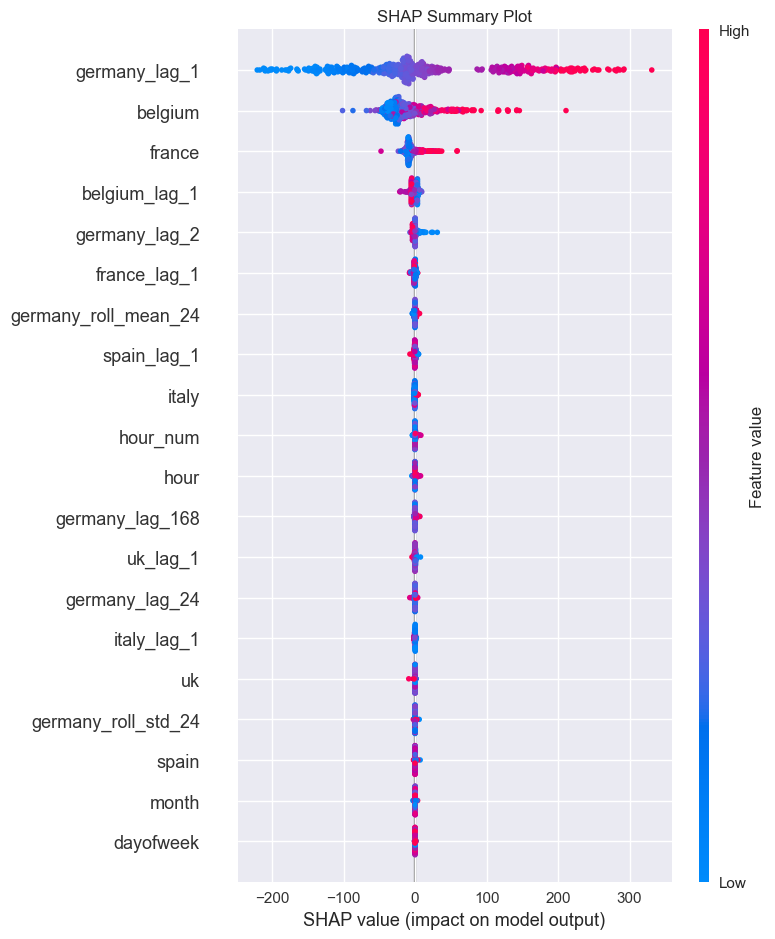

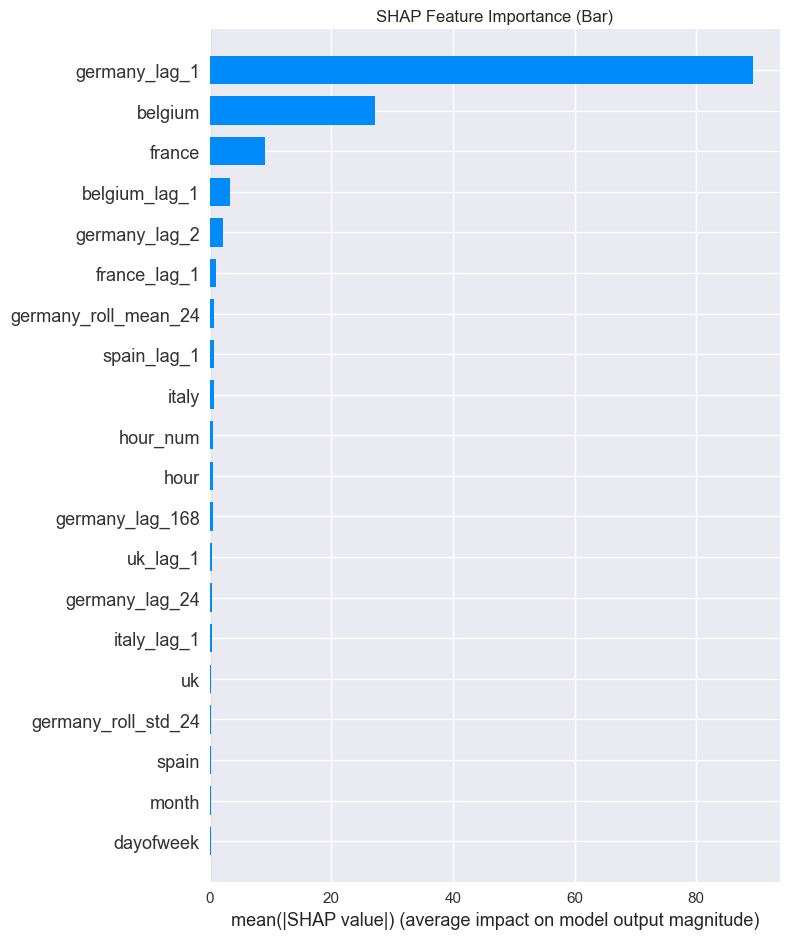

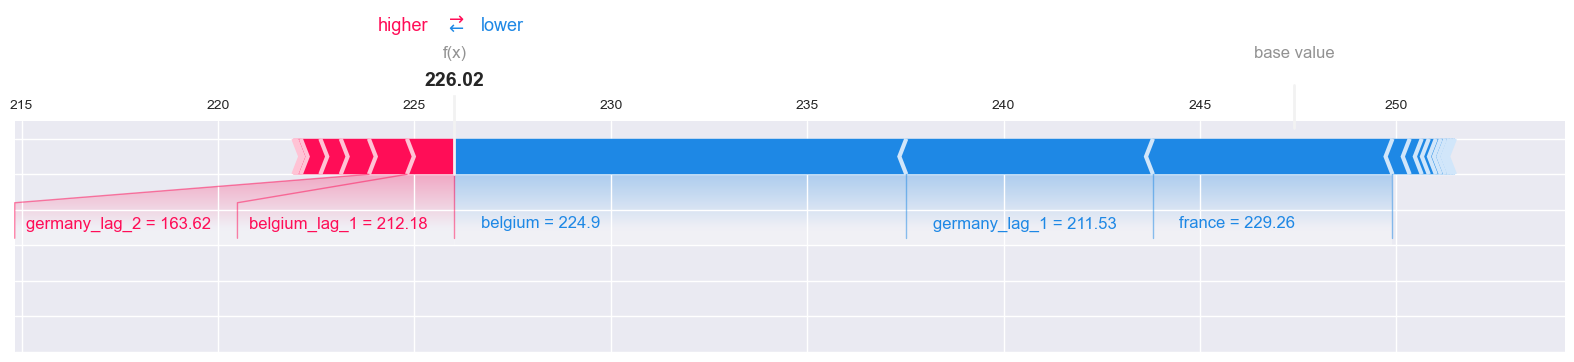

In [24]:
# ============================
# SHAP ANALYSIS
# ============================

import shap

# Use a small sample for speed (SHAP is heavy)
X_sample = X_train.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

print("SHAP analysis ready.")

# --- Summary Plot (Global Importance) ---
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_values, X_sample, plot_type="dot")

# --- Bar Plot (Global Importance) ---
plt.title("SHAP Feature Importance (Bar)")
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# --- Force Plot for a single prediction ---
idx = X_test.sample(1, random_state=42).index[0]
shap.force_plot(
    explainer.expected_value,
    explainer.shap_values(X_test.loc[idx]),
    X_test.loc[idx],
    matplotlib=True
)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 15}
Best MAE: 16.74588022894131

=== Tuned Model Performance ===
Random Forest (Tuned) → MAE: 10.898, RMSE: 19.021, WAPE: 5.47%


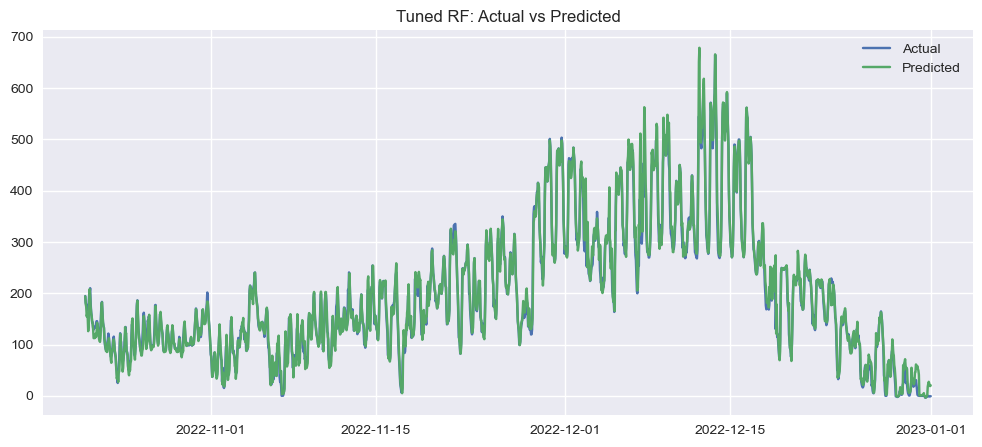

In [25]:
# ============================
# HYPERPARAMETER TUNING
# ============================

from sklearn.model_selection import RandomizedSearchCV



param_grid = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best MAE:", -search.best_score_)

# Train final tuned model
rf_tuned = search.best_estimator_

y_pred_tuned = pd.Series(rf_tuned.predict(X_test), index=y_test.index)

print("\n=== Tuned Model Performance ===")
evaluate(y_test, y_pred_tuned, "Random Forest (Tuned)")

plot_actual_vs_pred(y_test, y_pred_tuned, title="Tuned RF: Actual vs Predicted")


[0]	train-rmse:137.33532	test-rmse:132.32785
[1]	train-rmse:130.73782	test-rmse:125.83022
[2]	train-rmse:124.49062	test-rmse:120.14996
[3]	train-rmse:118.57678	test-rmse:114.52698
[4]	train-rmse:112.89380	test-rmse:108.90621
[5]	train-rmse:107.58059	test-rmse:103.98624
[6]	train-rmse:102.43579	test-rmse:98.91438
[7]	train-rmse:97.58122	test-rmse:94.00562
[8]	train-rmse:93.04477	test-rmse:89.45059
[9]	train-rmse:88.65366	test-rmse:85.07806
[10]	train-rmse:84.55625	test-rmse:81.02687
[11]	train-rmse:80.66421	test-rmse:77.09219
[12]	train-rmse:76.89814	test-rmse:73.49891
[13]	train-rmse:73.51300	test-rmse:70.12326
[14]	train-rmse:70.09494	test-rmse:66.92933
[15]	train-rmse:66.84335	test-rmse:63.84598
[16]	train-rmse:63.91201	test-rmse:61.18415
[17]	train-rmse:60.98062	test-rmse:58.46729
[18]	train-rmse:58.19967	test-rmse:55.87015
[19]	train-rmse:55.55733	test-rmse:53.35748
[20]	train-rmse:53.05297	test-rmse:51.05735
[21]	train-rmse:50.67210	test-rmse:48.85449
[22]	train-rmse:48.40973	test

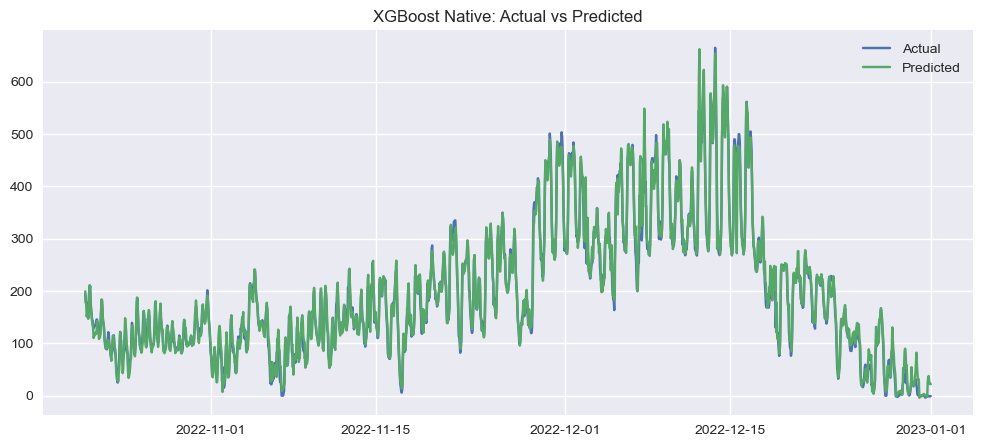

In [26]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    "objective": "reg:squarederror",
    "eta": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "rmse"
}

evals = [(dtrain, "train"), (dtest, "test")]

booster = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    early_stopping_rounds=50
)

y_pred_xgb = pd.Series(booster.predict(dtest), index=y_test.index)

print("\n=== XGBoost (Native API) Performance ===")
evaluate(y_test, y_pred_xgb, "XGBoost")

plot_actual_vs_pred(y_test, y_pred_xgb, title="XGBoost Native: Actual vs Predicted")
